# 06 - Part D again: find the camera from the image, every step

**The follow-up task.** The first Part D rendered poses it already knew. Here the camera's real
pose is hidden, every commanded move is executed with errors, and **after every move the camera
works out where it is from the image**, then decides its next move from that estimate. The
estimated angle should converge to 0, at 100 cm, looking at the centre.

Code: `src/aulecv/closed_loop.py`. Tests: `tests/test_closed_loop.py`.

In [1]:
# --- Setup: locate the project, check dependencies, import the package -------
# Local Jupyter: the project is found by walking up from the working directory.
# Google Colab: Drive is mounted and searched for the project folder. A folder
# that cannot be written to (for example one shared as view-only) is copied to
# /content first, so the notebook can save its outputs.
import glob, importlib.util, os, shutil, subprocess, sys

PROJECT_NAME = "AULE_ComputerVisionChallenge"
PROJECT_DIR = ""  # optional: set this to the project folder if it is not found automatically

def _is_project(path):
    return bool(path) and os.path.isdir(os.path.join(path, "src", "aulecv"))

def _walk_up(start):
    path = os.path.abspath(start)
    while not _is_project(path):
        parent = os.path.dirname(path)
        if parent == path:
            return None
        path = parent
    return path

def _is_writable(path):
    probe = os.path.join(path, "outputs", ".write_test")
    try:
        os.makedirs(os.path.dirname(probe), exist_ok=True)
        with open(probe, "w") as fh:
            fh.write("ok")
        os.remove(probe)
        return True
    except OSError:
        return False

IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = PROJECT_DIR if _is_project(PROJECT_DIR) else _walk_up(os.getcwd())

if PROJECT_ROOT is None and IN_COLAB:
    local_copy = os.path.join("/content", PROJECT_NAME)
    if _is_project(local_copy):
        PROJECT_ROOT = local_copy
    else:
        from google.colab import drive
        drive.mount("/content/drive")
        patterns = ["MyDrive/{}", "MyDrive/*/{}", "MyDrive/*/*/{}",
                    ".shortcut-targets-by-id/*/{}", ".shortcut-targets-by-id/*/*/{}",
                    "Shareddrives/*/{}"]
        found = [p for pat in patterns
                 for p in sorted(glob.glob(os.path.join("/content/drive", pat.format(PROJECT_NAME))))
                 if _is_project(p)]
        if not found:
            raise RuntimeError(
                "The {0} folder was not found in Google Drive. If it was shared with you, "
                "open Drive, right-click the shared folder and choose Organize > Add shortcut "
                "> My Drive, then run this cell again. Alternatively set PROJECT_DIR above."
                .format(PROJECT_NAME))
        PROJECT_ROOT = found[0]
        if not _is_writable(PROJECT_ROOT):
            shutil.copytree(PROJECT_ROOT, local_copy, dirs_exist_ok=True)
            print("Drive folder is read-only; working on a copy in", local_copy)
            PROJECT_ROOT = local_copy

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the {} folder. Open this notebook from inside it, "
                       "or set PROJECT_DIR above.".format(PROJECT_NAME))

_required = {"cv2": "opencv-python-headless", "numpy": "numpy", "pandas": "pandas",
             "matplotlib": "matplotlib", "imageio": "imageio", "PIL": "pillow"}
_missing = [pkg for mod, pkg in _required.items() if importlib.util.find_spec(mod) is None]
if _missing and IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)
elif _missing:
    raise ImportError("Missing packages: {}. Install them with: pip install -r "
                      "requirements.txt".format(", ".join(_missing)))

os.environ["AULECV_PROJECT_ROOT"] = PROJECT_ROOT
if os.path.join(PROJECT_ROOT, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import numpy as np, cv2, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

from aulecv import config as C, detect, rotation, navigation, camera, viz
from aulecv import io as aio

np.random.seed(C.RANDOM_SEED)
OUT = aio.ensure_output_dirs()
print("PROJECT_ROOT :", PROJECT_ROOT)
print("outputs      :", OUT)
print("python       :", sys.version.split()[0], "| opencv", cv2.__version__, "| numpy", np.__version__)
from aulecv import closed_loop as cl

PROJECT_ROOT : D:\Aulespace\AULE_ComputerVisionChallenge
outputs      : D:\Aulespace\AULE_ComputerVisionChallenge\outputs
python       : 3.14.3 | opencv 4.13.0 | numpy 2.4.3


## 1. Finding the pose from one image

Two steps:

1. **Four corners plus PnP.** Detect the outer square's corners and solve PnP against the real
   40 cm square. This is quick and robust. But near the front view, a slightly turned square looks
   almost unchanged, so the angle is weak (the original Part D showed this).
2. **Refine with every pixel.** Use the PnP answer as a starting guess, then align the whole
   reference image to the camera image (ECC, a dense image alignment). That gives the homography
   between them, using every pixel instead of four corners. Decomposition of `K^-1 H G^-1`
   seeds a final PnP fit to a 5 x 5 grid of ECC-aligned target points. These correlated points
   constrain a physical 6-DOF camera; they are not 25 independent feature detections.

If the alignment fails or scores badly, the corner answer is used and flagged.

In [2]:
reference = aio.load_reference()
ref_det = detect.detect_port(reference)
geom = camera.PortGeometry.from_detection(ref_det, reference.shape)
thetas = camera.generate_return_sequence(C.PART_C_ANGLE_DEG, C.PART_D_STEP_DEG)
renderA = camera.make_renderer(geom, thetas, "metric")
estimator = cl.PoseEstimator(reference, renderA.K, renderA.G)

rows = []
for true_theta in [22.5, 15.0, 10.0, 5.0, 2.5, 1.0, 0.5, 0.0]:
    probe = cl.OrbitCamera(reference, renderA, true_theta, 100.0, cl.PoseError(sensor_noise=2.0, seed=3))
    e = estimator.estimate(probe.capture())
    rows.append({"true_theta_deg": true_theta,
                 "corner_PnP_error_deg": e.corner_theta_deg - true_theta,
                 "dense_error_deg": e.theta_deg - true_theta,
                 "corner_distance_error_cm": e.corner_distance_cm - 100.0,
                 "dense_distance_error_cm": e.distance_cm - 100.0, "method": e.method})
acc = pd.DataFrame(rows)
display(acc.round(4))
print("worst corner-PnP angle error : {:.3f} deg".format(acc.corner_PnP_error_deg.abs().max()))
print("worst dense angle error      : {:.3f} deg".format(acc.dense_error_deg.abs().max()))
acc.to_csv(aio.output_path("camera_return", "followup_pose_accuracy.csv"), index=False)

,true_theta_deg,corner_PnP_error_deg,dense_error_deg,corner_distance_error_cm,dense_distance_error_cm,method
0,22.5,-0.1280,-0.0009,-0.1083,-0.0020,dense
1,15.0,0.1879,0.0046,-0.0882,0.0022,dense
2,10.0,-0.1202,0.0012,-0.1018,-0.0033,dense
3,5.0,0.5021,-0.0058,-0.0933,0.0022,dense
4,2.5,1.4306,-0.0091,-0.0883,-0.0035,dense
5,1.0,0.9212,0.0056,-0.0962,0.0035,dense
6,0.5,2.6467,-0.0108,-0.1830,-0.0003,dense
7,0.0,0.0171,0.0045,-0.0449,0.0019,dense


worst corner-PnP angle error : 2.647 deg
worst dense angle error      : 0.011 deg


The corner answer is off by over a degree near the front. The dense answer stays within a few
hundredths of a degree everywhere, with image noise added.

## 2. The simulated camera

`cl.OrbitCamera` keeps the true pose to itself and renders the image from it. The controller sends
a move in the camera's own frame: a translation plus a rotation. It's executed with errors:

- only **85%** of the commanded translation,
- random translation noise (0.05 cm per axis),
- random rotation noise (0.05 degrees per axis),
- image noise.

## 3. The closed loop

Each iteration:

1. Estimate the pose from the image.
2. Require full 3-D position within 0.1 cm of `(0, 0, -100)`, orientation, pointing and
   azimuth errors below 0.1 degrees, on two consecutive frames. Hold still for confirmation.
3. Otherwise aim for the orbit point up to 2.5 degrees closer to the front, at 100 cm, looking at
   the centre, and send the move needed to get there **from the estimated pose**. Distance and
   pointing errors get corrected on the way.

In [3]:
ERR = cl.PoseError(gain=0.85, noise_cm=0.05, rot_noise_deg=0.05, sensor_noise=2.0, seed=11)

class Recording(cl.OrbitCamera):
    def capture(self):
        img = super().capture(); self.frames.append(img); return img

def run(refine):
    c = Recording(reference, renderA, 22.5, 100.0, ERR); c.frames = []
    res = cl.return_to_front_closed_loop(c, estimator, refine=refine)
    # Truth stays in the evaluator, outside the controller's interface.
    return c, res, pd.concat([pd.DataFrame(res.log), pd.DataFrame(c.observations)], axis=1)

cam_dense, res_dense, log_dense = run(True)
cam_corner, res_corner, log_corner = run(False)
print("dense  : {} after {} iterations | true angle {:.3f} deg, true distance {:.3f} cm"
      .format(res_dense.status, res_dense.iterations, cam_dense.true_theta_deg, cam_dense.true_distance_cm))
print("corners: {} after {} iterations | true angle {:.3f} deg, true distance {:.3f} cm"
      .format(res_corner.status, res_corner.iterations, cam_corner.true_theta_deg, cam_corner.true_distance_cm))
display(log_dense[["iteration", "true_theta_deg", "est_theta_deg", "corner_theta_deg",
                   "true_distance_cm", "est_distance_cm", "true_pointing_err_deg", "method"]].round(4))
log_dense.to_csv(aio.output_path("camera_return", "followup_closed_loop_dense.csv"), index=False)
log_corner.to_csv(aio.output_path("camera_return", "followup_closed_loop_corners.csv"), index=False)

dense  : converged after 16 iterations | true angle -0.017 deg, true distance 99.942 cm
corners: not_converged after 30 iterations | true angle -0.664 deg, true distance 100.192 cm


,iteration,true_theta_deg,est_theta_deg,corner_theta_deg,true_distance_cm,est_distance_cm,true_pointing_err_deg,method
0,0,22.5000,22.4998,22.3751,100.0000,99.9994,0.0000,dense
1,1,20.3792,20.3824,20.4882,99.9642,99.9648,0.3086,dense
2,2,18.2753,18.2753,18.3128,100.0355,100.0359,0.4458,dense
3,3,16.1475,16.1441,16.0998,99.9767,99.9746,0.3381,dense
4,4,14.0688,14.0663,14.0086,99.9371,99.9358,0.4643,dense
5,5,11.9666,11.9670,11.6354,100.0303,100.0289,0.3411,dense
6,6,9.8037,9.8032,9.7576,100.0270,100.0286,0.3180,dense
7,7,7.6812,7.6864,7.8172,99.9447,99.9419,0.2744,dense
8,8,5.5288,5.5368,5.2638,100.0424,100.0392,0.4144,dense
9,9,3.3889,3.3900,3.2907,99.9338,99.9308,0.3586,dense


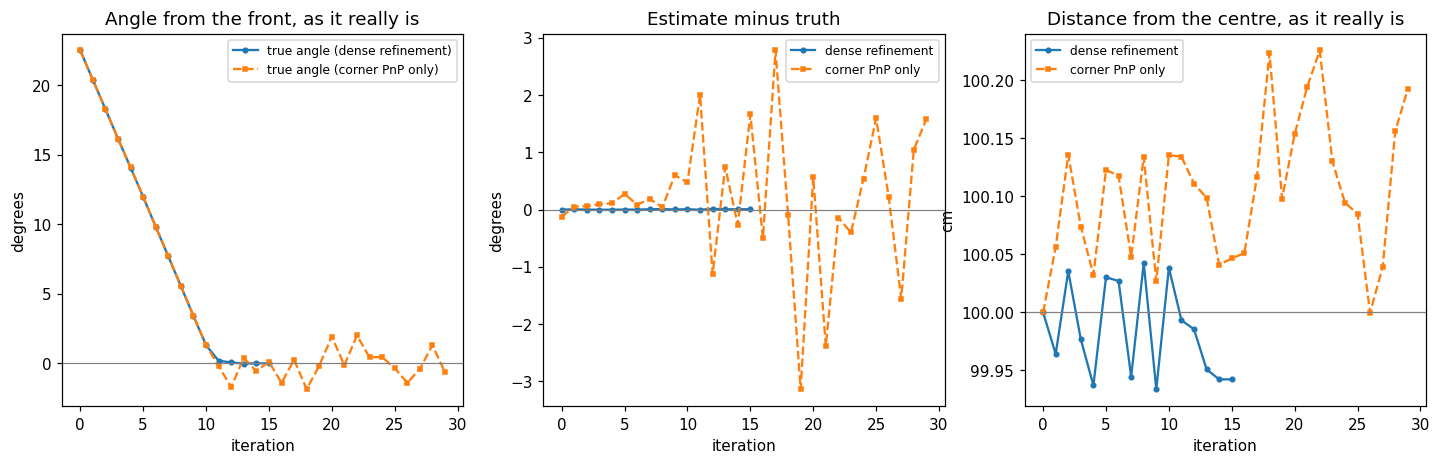

wrote outputs\camera_return\followup_closed_loop_return.gif


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for lg, name, style in [(log_dense, "dense refinement", "o-"), (log_corner, "corner PnP only", "s--")]:
    axes[0].plot(lg.iteration, lg.true_theta_deg, style, ms=3, label=f"true angle ({name})")
    axes[1].plot(lg.iteration, lg.est_theta_deg - lg.true_theta_deg, style, ms=3, label=name)
    axes[2].plot(lg.iteration, lg.true_distance_cm, style, ms=3, label=name)
axes[0].axhline(0, color="grey", lw=0.8); axes[0].set_title("Angle from the front, as it really is")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("degrees"); axes[0].legend(fontsize=8)
axes[1].axhline(0, color="grey", lw=0.8); axes[1].set_title("Estimate minus truth")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("degrees"); axes[1].legend(fontsize=8)
axes[2].axhline(100, color="grey", lw=0.8); axes[2].set_title("Distance from the centre, as it really is")
axes[2].set_xlabel("iteration"); axes[2].set_ylabel("cm"); axes[2].legend(fontsize=8)
fig.savefig(aio.output_path("camera_return", "followup_convergence.png"), bbox_inches="tight"); plt.show()
gif = viz.save_gif(aio.output_path("camera_return", "followup_closed_loop_return.gif"), cam_dense.frames, fps=4)
print("wrote", os.path.relpath(gif, PROJECT_ROOT))

**With dense refinement** the estimate tracks the truth to about a hundredth of a degree, and the
camera settles at the front.

**With corners only** it never settles. Near the front its estimate is off by a degree or more, so
it keeps "correcting" errors that aren't there and hunts back and forth around 0. That's the
near-front weakness from the original Part D, and now it has a fix.

## 4. Many runs with random errors

In [5]:
rng = np.random.default_rng(C.RANDOM_SEED); rows = []
for k in range(8):
    err = cl.PoseError(gain=float(rng.uniform(0.7, 1.2)), noise_cm=0.05, rot_noise_deg=0.05,
                       sensor_noise=2.0, seed=int(rng.integers(1e9)))
    for refine in (True, False):
        c = cl.OrbitCamera(reference, renderA, 22.5, 100.0, err)
        res = cl.return_to_front_closed_loop(c, estimator, refine=refine)
        last = res.log[-1]
        rows.append({"run": k, "method": "dense refinement" if refine else "corner PnP only",
                     "motion_gain": round(err.gain, 3), "status": res.status, "iterations": res.iterations,
                     "final_true_angle_deg": c.true_theta_deg, "final_true_distance_cm": c.true_distance_cm,
                     "final_estimate_error_deg": last["est_theta_deg"] - c.observations[-1]["true_theta_deg"],
                     "final_position_error_cm": np.linalg.norm(c.true_center - [0, 0, -100]),
                     "final_pointing_error_deg": c.true_pointing_error_deg,
                     "max_radius_deviation_cm": max(abs(o["true_distance_cm"] - 100) for o in c.observations)})
runs = pd.DataFrame(rows)
runs.to_csv(aio.output_path("camera_return", "followup_closed_loop_runs.csv"), index=False)
summary = runs.groupby("method").agg(
    converged=("status", lambda s: f"{(s == 'converged').sum()} of {len(s)}"),
    median_iterations=("iterations", "median"),
    worst_final_angle_deg=("final_true_angle_deg", lambda s: s.abs().max()),
    worst_final_distance_error_cm=("final_true_distance_cm", lambda s: (s - 100).abs().max()),
    worst_estimate_error_deg=("final_estimate_error_deg", lambda s: s.abs().max()),
    worst_position_error_cm=("final_position_error_cm", "max"),
    worst_pointing_error_deg=("final_pointing_error_deg", "max"),
    worst_radius_deviation_cm=("max_radius_deviation_cm", "max"))
display(summary.round(4))

,converged,median_iterations,worst_final_angle_deg,worst_final_distance_error_cm,worst_estimate_error_deg,worst_position_error_cm,worst_pointing_error_deg,worst_radius_deviation_cm
method,,,,,,,,
corner PnP only,0 of 8,30.0,2.6704,0.2385,2.0470,5.5890,0.4292,0.3702
dense refinement,8 of 8,13.5,0.0767,0.0852,0.0327,0.1387,0.0986,0.1472


## 5. Limitations

- The images are rendered with the same flat-target model the estimator assumes, so the dense
  alignment sees near-ideal images apart from the added noise. ECC tolerates global brightness
  and contrast changes, but local shadows, reflections, occlusion and lens distortion remain risks. The corner
  PnP step is there as the robust fallback, and a real system would calibrate the lens first.
- The camera's internal settings (K) are assumed known, as in Part C.
- The motion between images is modelled as a translation plus a rotation with random errors. Real
  orbital motion is different: holding a circle around a target needs continuous thrust.
- 100 cm is the commanded orbit, not a guarantee at every instant under unknown motion errors.
  The experiment reports the maximum observed radial deviation and the final full-pose error.
  Continuous path constraints need low-level control and more frequent sensing.
- Convergence is judged on the **estimate**. The tables report the truth alongside it, but a real
  system would only have the estimate.